In [1]:
# 7DT Library
from astropy.table import Table
from astropy import constants as const
from astropy.io import ascii
import glob, os
import sys

sys.path.append('..')
from simulator.helper import *
from simulator.sdtpy import *
register_custom_filters_on_speclite('../simulator')

# plt.style.use('dark_background') # Dark Mode Style

Use `med25nm`, `med50nm`, `broad` as `group_name`


In [2]:
#	Subsequent filter info [AA]
bandmin=4000
bandmax=9000
bandwidth=250
bandstep=125
#	Maximum transmission of each filters
bandrsp=0.95
#	Wavelength bin [AA]
lammin=1000
lammax=10000
lamres=1000

In [3]:
#	Seeing Condition
seeing = 2.0

In [4]:
eff_factor = 0.7
exptime_single = 300.

D             : 50.5cm
D_obscuration : 29.8cm
Deff          : 40.770cm


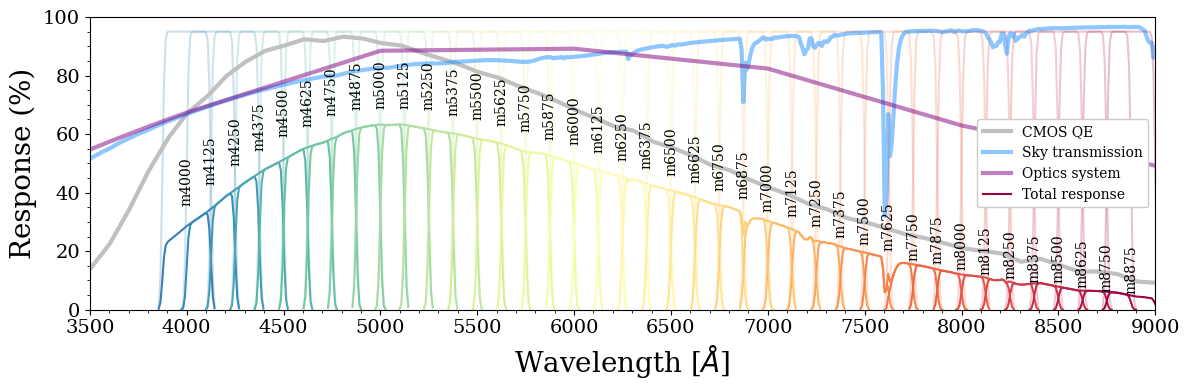

In [5]:
#	Exposure Time [s]
sdt = SevenDT()
sdt.echo_optics()
filterset = sdt.generate_filterset(bandmin=bandmin, bandmax=bandmax, bandwidth=bandwidth, bandstep=bandstep, bandrsp=bandrsp, lammin=lammin, lammax=lammax, lamres=lamres)
T_qe = sdt.get_CMOS_IMX455_QE()
sdt.get_optics()
s = sdt.get_sky()
sdt.smooth_sky()
totrsptbl = sdt.calculate_response()
Npix_ptsrc, Narcsec_ptsrc = sdt.get_phot_aperture(exptime=exptime_single, fwhm_seeing=seeing, optfactor=1.0, verbose=False)
depthtbl = sdt.get_depth_table(Nsigma=5)
sdt.get_speclite()

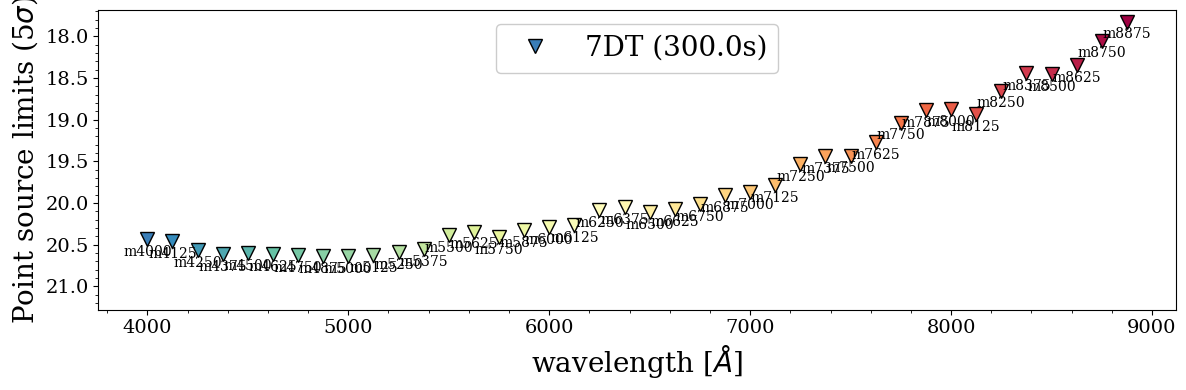

In [6]:
sdt.plot_point_source_depth()